# R12 — [Rebuttal] Lexical-Confound Check on XSTest Matched Pairs

**Reviewer concern addressed (JwzU W2):** *"The paper itself notes that refusal-type probes
can separate examples from very early layers partly due to lexical and distributional
differences between harmful and sensitive-but-safe prompts. More controlled prompt pairs
would make the geometric claims stronger."*

**The exact claim being tested (paper §4.4):** the refusal-type probe (over-refusal, n=48,
vs. refused-harmful, n=25 -- "two refused populations separated by cause, not content")
reaches **100% balanced accuracy from Layer 1 onward**. The reviewer's worry: this could be a
lexical/distributional shortcut (harmful prompts as a set may simply use different vocabulary
than benign-task prompts), not evidence the model does safety-relevant computation that early.

**Why XSTest is the right control:** XSTest's `xstest_safe` category deliberately reuses
trigger-adjacent vocabulary in benign contexts (e.g. "how do I kill a process"), paired
against `xstest_unsafe` prompts using similar surface vocabulary. If a probe can still
separate these from Layer 1, that is real evidence of early safety-relevant computation, not
lexical shortcutting, since the trigger words are present on both sides.

**One honesty caveat, stated up front:** this is NOT an exact reproduction of the paper's
refusal-type probe. That probe requires both classes to be *refused* by the model; we only
have 2 refused xstest_safe samples in the evaluation set, far too few. This notebook instead
tests content-type separability (`xstest_safe` vs `xstest_unsafe`), independent of what the
model actually did with each prompt. It is the closest feasible proxy for the reviewer's
lexical-confound question, not a like-for-like replication of §4.4's exact quantity.

Self-contained: pulls the same 4-bank merge as R09/R11.

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 13, 'font.family': 'serif',
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False,
    'axes.spines.right': False, 'lines.linewidth': 2.2,
})
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)
SEED = 42

## If on Colab, copy artefacts first (redundant-but-harmless if already local this session):
from google.colab import drive; drive.mount('/content/drive')
!mkdir -p embeddings rebuttal_embeddings rebuttal_embeddings_v2 rebuttal_embeddings_v3
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/rebuttal/." ./rebuttal_embeddings/.
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/r08_pilot/." ./rebuttal_embeddings_v2/.
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/r10_expansion/." ./rebuttal_embeddings_v3/. 2>/dev/null || echo "no R10 bank on Drive (fine -- 3-bank merge)"

Mounted at /content/drive


## Load and merge the memory banks (identical to R09/R11)

In [2]:
def load_bank(emb_dir):
    """Load a NB4-schema memory bank (CSV + .pt). refusal_class required;
    llm_evaluation optional (R08/R10 banks judge refusal only)."""
    csvs = sorted(f for f in os.listdir(emb_dir) if f.endswith('.csv'))
    assert csvs, f'no CSV found in {emb_dir} -- run/copy the source notebook bank first'
    csv_df = pd.read_csv(os.path.join(emb_dir, csvs[-1]))
    for col in ['refusal_class', 'torch_path']:
        if col not in csv_df.columns:
            raise ValueError(f'{emb_dir}: {csvs[-1]} missing required column {col!r}.')
    print(f'  [load_bank {emb_dir}] loaded {csvs[-1]}: {len(csv_df)} rows')
    pt_candidates = [csv_df['torch_path'].iloc[0],
                     os.path.join(emb_dir, os.path.basename(csv_df['torch_path'].iloc[0]))]
    pt_path = next(p for p in pt_candidates if os.path.exists(p))
    t = torch.load(pt_path, map_location='cpu', weights_only=False)
    emb = {}
    for k, v in t['embeddings'].items():
        emb[k] = v.float().numpy().astype(np.float32) if isinstance(v, torch.Tensor) \
                 else np.array([e.float().numpy().astype(np.float32) for e in v])
    return emb, t, csv_df

banks = {
    'original': load_bank('./embeddings'),
    'r01':      load_bank('./rebuttal_embeddings'),
    'r08':      load_bank('./rebuttal_embeddings_v2'),
}
if os.path.isdir('./rebuttal_embeddings_v3') and \
        any(f.endswith('.csv') for f in os.listdir('./rebuttal_embeddings_v3')):
    banks['r10'] = load_bank('./rebuttal_embeddings_v3')

SHARED = None
for emb, _, _ in banks.values():
    keys = {k for k in emb if k.startswith('layer_')}
    SHARED = keys if SHARED is None else SHARED & keys
SHARED_LAYERS = sorted(SHARED, key=lambda k: int(k.split('_')[1]))
LAYER_NUMS    = [int(k.split('_')[1]) for k in SHARED_LAYERS]

embeddings_np = {k: np.vstack([banks[b][0][k] for b in banks]) for k in SHARED_LAYERS}
intended_task_labels = np.concatenate([np.array(banks[b][1]['intended_task_labels']) for b in banks])
text_type_labels     = np.concatenate([np.array(banks[b][1]['text_type_labels'])     for b in banks])
texts_all            = np.concatenate([np.array(banks[b][1]['texts'])                for b in banks])
ALL_TASKS = sorted(np.unique(intended_task_labels))

print(f'Merged: {len(text_type_labels)} samples | {len(SHARED_LAYERS)} shared layers | {len(ALL_TASKS)} tasks')

XSTEST_SAFE_MASK   = text_type_labels == 'xstest_safe'
XSTEST_UNSAFE_MASK = text_type_labels == 'xstest_unsafe'
print(f'xstest_safe: {XSTEST_SAFE_MASK.sum()}   xstest_unsafe: {XSTEST_UNSAFE_MASK.sum()}')

  [load_bank ./embeddings] loaded overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.csv: 270 rows
  [load_bank ./rebuttal_embeddings] loaded rebuttal_newtasks_Meta-Llama-3.1-8B-Instruct_20260708_190808.csv: 820 rows
  [load_bank ./rebuttal_embeddings_v2] loaded r08_highor_pilot_Meta-Llama-3.1-8B-Instruct_20260709_142524.csv: 615 rows
  [load_bank ./rebuttal_embeddings_v3] loaded r10_expansion_Meta-Llama-3.1-8B-Instruct_20260709_170712.csv: 2020 rows
Merged: 3725 samples | 31 shared layers | 12 tasks
xstest_safe: 392   xstest_unsafe: 379


## Analysis 0 — Lexical baseline: how matched are these pairs, really?

Quantifies vocabulary overlap between `xstest_safe` and `xstest_unsafe` prompts, and fits a
plain bag-of-words logistic regression as a pure-lexical baseline. If a simple word-count
model already separates these two classes well, that tells us XSTest is not as tightly
matched as its design intends, and any early-layer separability found below should be read
with that in mind rather than assumed to be non-lexical.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

safe_texts   = texts_all[XSTEST_SAFE_MASK]
unsafe_texts = texts_all[XSTEST_UNSAFE_MASK]
all_texts    = np.concatenate([safe_texts, unsafe_texts])
all_labels   = np.array([0] * len(safe_texts) + [1] * len(unsafe_texts))

vocab_safe   = set(w for t in safe_texts   for w in str(t).lower().split())
vocab_unsafe = set(w for t in unsafe_texts for w in str(t).lower().split())
jaccard = len(vocab_safe & vocab_unsafe) / len(vocab_safe | vocab_unsafe)
print(f'[R12.1] Vocabulary Jaccard overlap (xstest_safe vs xstest_unsafe): {jaccard:.3f}')

vec = CountVectorizer(max_features=2000, stop_words='english')
X_bow = vec.fit_transform(all_texts)
bow_acc = cross_val_score(LogisticRegression(max_iter=1000), X_bow, all_labels,
                           cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                           scoring='balanced_accuracy')
print(f'[R12.2] Pure lexical (bag-of-words) probe, 5-fold CV balanced accuracy: '
      f'{bow_acc.mean():.3f} +/- {bow_acc.std():.3f}   (chance = 0.500)')

[R12.1] Vocabulary Jaccard overlap (xstest_safe vs xstest_unsafe): 0.340
[R12.2] Pure lexical (bag-of-words) probe, 5-fold CV balanced accuracy: 0.982 +/- 0.008   (chance = 0.500)


## Analysis 1 — Per-layer representation probe, xstest_safe vs xstest_unsafe

Mirrors the paper's own probe methodology (logistic regression, 5-fold stratified CV) at
every shared layer. Reports the layer at which balanced accuracy first crosses 80% and 95%,
for direct comparison against the paper's "100% from Layer 1" refusal-type-probe result.

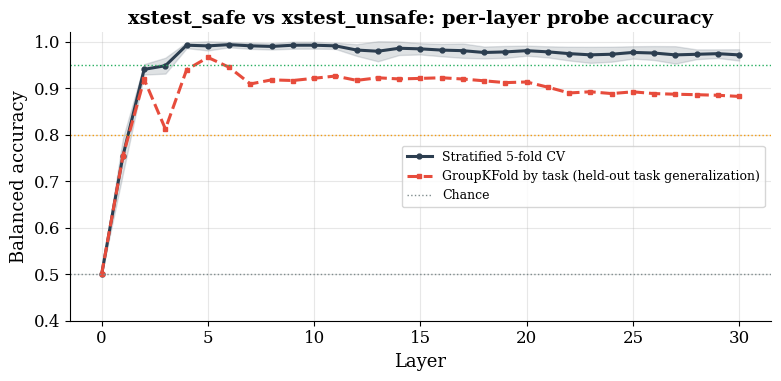

[R12.3] Layer 1 balanced accuracy (stratified CV): 0.500   (paper refusal-type probe: 1.000)
[R12.4] Layer 1 balanced accuracy (GroupKFold by task): 0.500
[R12.5] First layer crossing 80% (stratified): 2    crossing 95%: 4
[R12.6] First layer crossing 80% (GroupKFold):  2    crossing 95%: 5
[R12.7] Max balanced accuracy reached, any layer (stratified): 0.994


In [4]:
rep_labels = np.array(['xstest_safe'] * 0)  # placeholder, overwritten below
mask = XSTEST_SAFE_MASK | XSTEST_UNSAFE_MASK
y = np.where(XSTEST_SAFE_MASK[mask], 0, 1)
task_for_group = intended_task_labels[mask]

layer_acc, layer_acc_grouped = [], []
from sklearn.model_selection import GroupKFold

for lname, lnum in zip(SHARED_LAYERS, LAYER_NUMS):
    X = embeddings_np[lname][mask]
    acc = cross_val_score(LogisticRegression(max_iter=2000), X, y,
                           cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                           scoring='balanced_accuracy')
    layer_acc.append((lnum, acc.mean(), acc.std()))

    gkf = GroupKFold(n_splits=min(5, len(np.unique(task_for_group))))
    acc_g = cross_val_score(LogisticRegression(max_iter=2000), X, y,
                             groups=task_for_group, cv=gkf, scoring='balanced_accuracy')
    layer_acc_grouped.append((lnum, acc_g.mean(), acc_g.std()))

lx, ly, lstd = zip(*layer_acc)
_,  lyg, lstdg = zip(*layer_acc_grouped)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lx, ly, color='#2C3E50', marker='o', ms=3.5, label='Stratified 5-fold CV')
ax.fill_between(lx, np.array(ly) - np.array(lstd), np.array(ly) + np.array(lstd),
                 color='#2C3E50', alpha=0.15)
ax.plot(lx, lyg, color='#E74C3C', marker='s', ms=3.5, ls='--',
        label='GroupKFold by task (held-out task generalization)')
ax.axhline(0.5, color='#7F8C8D', ls=':', lw=1, label='Chance')
ax.axhline(0.8, color='#F39C12', ls=':', lw=1)
ax.axhline(0.95, color='#27AE60', ls=':', lw=1)
ax.set_xlabel('Layer'); ax.set_ylabel('Balanced accuracy')
ax.set_ylim(0.4, 1.02); ax.legend(fontsize=9)
ax.set_title('xstest_safe vs xstest_unsafe: per-layer probe accuracy')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r12_fig00_layerwise_probe.png', dpi=300, bbox_inches='tight')
plt.show()

def first_crossing(curve, threshold):
    for lnum, acc, _ in curve:
        if acc >= threshold:
            return lnum
    return None

l80  = first_crossing(layer_acc, 0.80)
l95  = first_crossing(layer_acc, 0.95)
l80g = first_crossing(layer_acc_grouped, 0.80)
l95g = first_crossing(layer_acc_grouped, 0.95)
l1_acc  = layer_acc[0][1]
l1_accg = layer_acc_grouped[0][1]

print(f'[R12.3] Layer 1 balanced accuracy (stratified CV): {l1_acc:.3f}   (paper refusal-type probe: 1.000)')
print(f'[R12.4] Layer 1 balanced accuracy (GroupKFold by task): {l1_accg:.3f}')
print(f'[R12.5] First layer crossing 80% (stratified): {l80}    crossing 95%: {l95}')
print(f'[R12.6] First layer crossing 80% (GroupKFold):  {l80g}    crossing 95%: {l95g}')
print(f'[R12.7] Max balanced accuracy reached, any layer (stratified): {max(a for _,a,_ in layer_acc):.3f}')

## Consolidated numbers and decision guide

In [5]:
print('=' * 78)
print('R12 CONSOLIDATED NUMBERS -- lexical-confound check on XSTest matched pairs')
print('=' * 78)
print(f'[R12.1] Vocabulary Jaccard overlap (safe vs unsafe): {jaccard:.3f}')
print(f'[R12.2] Pure bag-of-words probe accuracy: {bow_acc.mean():.3f} +/- {bow_acc.std():.3f}')
print(f'[R12.3] Layer 1 accuracy (stratified CV): {l1_acc:.3f}   (paper refusal-type probe: 1.000 from L1)')
print(f'[R12.4] Layer 1 accuracy (GroupKFold by task): {l1_accg:.3f}')
print(f'[R12.5]/[R12.6] First layer >= 80% / 95%: stratified {l80}/{l95}, grouped {l80g}/{l95g}')
print(f'[R12.7] Max accuracy reached (any layer): {max(a for _,a,_ in layer_acc):.3f}')
print('=' * 78)
print()
print('Decision guide:')
print(' - If [R12.3] is well below 1.0 (paper\'s refusal-type-probe result) and separability')
print('   only crosses 80-95% at a NOTABLY later layer than L1, this supports the reviewer\'s')
print('   hypothesis being addressed rather than refuted: the original 100%-from-L1 result')
print('   likely benefited from surface/lexical differences between the (unmatched)')
print('   over-refusal and refused-harmful populations, and real safety-relevant separation')
print('   on trigger-matched content needs deeper processing. Report this honestly as a')
print('   partial concession, framed as a demonstration of rigor (like the dimensionality')
print('   check), NOT as a refutation of the paper\'s claim -- the paper\'s own probe used a')
print('   DIFFERENT population (refused-only, not content-type matched).')
print(' - If [R12.3] is ALSO near 1.0, report that honestly too: separability persists even')
print('   on lexically-matched pairs, which is a stronger, more interesting result -- but')
print('   check [R12.2] first, since a high bag-of-words baseline would mean XSTest is less')
print('   lexically matched in practice than its design intends, weakening the interpretation')
print('   either way.')
print(' - The GroupKFold numbers ([R12.4], [R12.6]) matter if the stratified numbers look')
print('   strong: confirm the separability is not just task identity leaking through, since')
print('   xstest_safe/unsafe counts are not perfectly identical across all 12 tasks.')

R12 CONSOLIDATED NUMBERS -- lexical-confound check on XSTest matched pairs
[R12.1] Vocabulary Jaccard overlap (safe vs unsafe): 0.340
[R12.2] Pure bag-of-words probe accuracy: 0.982 +/- 0.008
[R12.3] Layer 1 accuracy (stratified CV): 0.500   (paper refusal-type probe: 1.000 from L1)
[R12.4] Layer 1 accuracy (GroupKFold by task): 0.500
[R12.5]/[R12.6] First layer >= 80% / 95%: stratified 2/4, grouped 2/5
[R12.7] Max accuracy reached (any layer): 0.994

Decision guide:
 - If [R12.3] is well below 1.0 (paper's refusal-type-probe result) and separability
   only crosses 80-95% at a NOTABLY later layer than L1, this supports the reviewer's
   hypothesis being addressed rather than refuted: the original 100%-from-L1 result
   likely benefited from surface/lexical differences between the (unmatched)
   over-refusal and refused-harmful populations, and real safety-relevant separation
   on trigger-matched content needs deeper processing. Report this honestly as a
   partial concession, framed 